## Load Dataset

In [1]:
import os 
import tarfile 
from urllib import request

download_root = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
Housing_path = os.path.join("datasets","housing")
Housing_url = download_root + "datasets/housing/housing.tgz"

# def fetch_data(housing_url = Housing_url,housing_path = Housing_path):
#     os.makedirs(housing_path,exist_ok=True)
#     tgz_path = os.path.join(housing_path,"housing.tgz")
#     request.urlretrieve(housing_url,tgz_path)
#     housing_tgz = tarfile.open(tgz_path)
#     housing_tgz.extractall(path=housing_path)
#     housing_tgz.close()

    
import pandas as pd 
def load_data(housing_path=Housing_path):
    csv_path = os.path.join(housing_path,"housing.csv")
    return pd.read_csv(csv_path)

housing = load_data()
housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [8]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
%matplotlib inline
# import matplotlib.pyplot as plt 
# housing.hist(bins = 50,figsize=(20,15))
# plt.show()


In [10]:
from sklearn.model_selection import train_test_split
train_set,test_set = train_test_split(housing,test_size = 0.2,random_state = 42)


<Axes: >

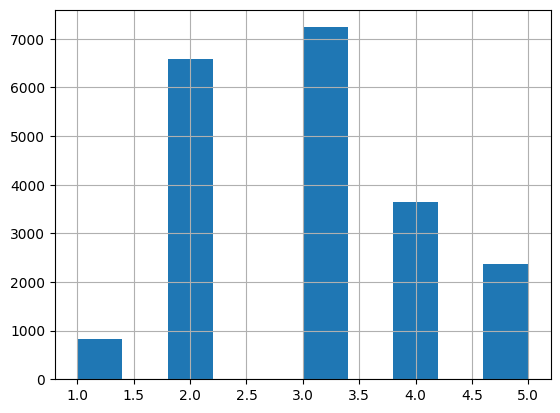

In [8]:
import numpy as np
# housing["median_income"]
housing["income_cat"] = pd.cut(housing["median_income"],bins = [0.,1.5,3.0,4.5,6.,np.inf],labels = [1,2,3,4,5,])
housing["income_cat"].hist()

In [13]:
from sklearn.model_selection import StratifiedShuffleSplit as sss
split = sss(n_splits = 1,test_size = 0.2 ,random_state = 42)
for train_index , test_index in split.split(housing , housing["income_cat"]):
    strat_train_set = housing.iloc[train_index]
    strat_test_set = housing.iloc[test_index]

strat_test_set["income_cat"].value_counts()/len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [ ]:
# for set_ in (strat_train_set,strat_test_set):
#     set_.drop("incom_cat",axis = 1 , inplace = True )

In [94]:
housing = strat_train_set.copy()


In [95]:
housing_df = housing.select_dtypes(include=['number'])
corr_matrix =  housing_df.corr()
corr_matrix["median_house_value"].sort_values(ascending = False)



median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

In [96]:
from pandas.plotting import scatter_matrix
attributes=["median_house_value" ,   
"median_income" ,       
"total_rooms"  ,        
"housing_median_age"  ,  
"households" ,           
"total_bedrooms" ,       
"population" ,          
"longitude" ,           
"latitude" ]

# scatter_matrix(housing[attributes],figsize = (12,8))
# housing.plot(kind = "scatter",x ="median_income",y = "median_house_value",alpha = 0.1)

In [97]:
# housing.info()

In [98]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


In [99]:
from sklearn.preprocessing import OrdinalEncoder

# ordinal_incoder = OrdinalEncoder()

# housing_cat_incoded = ordinal_incoder.fit_transform(housing_cat)
# housing_cat_incoded[:10]

In [100]:
# ordinal_incoder.categories_

In [101]:
# from sklearn.preprocessing import OneHotEncoder
# cat_encoder = OneHotEncoder()
# housing_cat1hot = cat_encoder.fit_transform(housing_cat)
# housing_cat1hot

In [102]:
# housing_cat1hot.toarray()

In [103]:
housing = strat_train_set.drop("median_house_value",axis = 1)
housing_labels = strat_train_set["median_house_value"].copy()

## Data Cleaning

In [18]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer()
housing_num = housing.drop("ocean_proximity",axis = 1)
housing_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


In [10]:
X = imputer.fit_transform(housing_num)


## Pipelines

NameError: name 'sss' is not defined

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([('imputer',SimpleImputer(strategy="median")),('std_scaler',StandardScaler()),])
housing_num_tr = num_pipeline.fit_transform(housing_num)

housing_num_tr[0]

array([-1.32783522,  1.05254828,  0.98214266, -0.8048191 , -0.97247648,
       -0.9744286 , -0.97703285,  2.34476576,  2.12963148,  1.89012782])

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder 
num_attr = list(housing_num.columns)
cat_attr = ["ocean_proximity"]
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attr),
    ('cat', OneHotEncoder(), cat_attr)
])
housing_prep = full_pipeline.fit_transform(housing)

housing_prep[0]

array([-1.32783522,  1.05254828,  0.98214266, -0.8048191 , -0.97247648,
       -0.9744286 , -0.97703285,  2.34476576,  2.12963148,  1.89012782,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ])

In [108]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(housing_prep,housing_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [109]:
some_data = housing.iloc[:5]
some_labels = housing_labels[:5]

In [110]:
some_data_prep = full_pipeline.transform(some_data)

In [111]:
lin_reg.predict(some_data_prep)

array([ 87710.9184376 , 312666.78080576, 148193.92872405, 181973.84391033,
       242269.47566914])

In [112]:
list(some_labels)


[72100.0, 279600.0, 82700.0, 112500.0, 238300.0]

In [113]:
from sklearn.metrics import mean_squared_error
predictions = lin_reg.predict(housing_prep)
lin_mse = mean_squared_error(housing_labels,predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68866.78550087014)

In [114]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prep,housing_labels)
housing_predict = tree_reg.predict(housing_prep)
tree_mse = mean_squared_error(housing_labels, housing_predict) 
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

In [115]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg,housing_prep,housing_labels,scoring="neg_mean_squared_error")
tree_rmse_scores = np.sqrt(-scores)
print(tree_rmse_scores.mean(),
tree_rmse_scores.std())


70230.71388848973 871.6805234663622


In [116]:
scores = cross_val_score(lin_reg,housing_prep,housing_labels,scoring="neg_mean_squared_error")
linear_rmse_scores = np.sqrt(-scores)
print(linear_rmse_scores.mean(),
linear_rmse_scores.std())


69034.06103362034 644.7517342589124


In [117]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(housing_prep,housing_labels)


RandomForestRegressor()

In [ ]:
housing_predict = model.predict(housing_prep)
mse = mean_squared_error(housing_labels, housing_predict) 
rmse = np.sqrt(mse)

scores = cross_val_score(model,housing_prep,housing_labels,scoring="neg_mean_squared_error")
fore_rmse_scores = np.sqrt(-scores)

# print(fore_rmse_scores.mean(),fore_rmse_scores.std())
print(f"Mean Squred Error = {mse} \n Root Mean Squred Error = {rmse} \n Cross validation Score  = {fore_rmse_scores.mean()}\n {fore_rmse_scores.std()}")

In [ ]:
# import joblib
# joblib.dump(model,"House_prise_prediction_model.joblib")


In [ ]:
# my_model = joblib.load("House_prise_prediction_model.joblib")

# prediction = my_model.predict(housing_prep)
# prediction

In [ ]:
# from sklearn.model_selection import GridSearchCV
# param_gid = [{'n_estimators':[3,10,30],'max_features':[2,4,6,8]},{'bootstrap':[False],'n_estimators':[3,10],'max_features':[2,3,4]}]
# forest_reg = RandomForestRegressor()
# grid_search = GridSearchCV(forest_reg,param_gid,cv = 5,scoring = 'neg_mean_squared_error',return_train_score = True)
# grid_search.fit(housing_prep,housing_labels)


In [ ]:
# grid_search.best_params_

In [ ]:
# finalmodel = grid_search.best_estimator_

In [ ]:
# pre = finalmodel.predict(housing_prep)

# ran_mse = mean_squared_error(housing_labels, housing_predict) 
# ran_rmse = np.sqrt(ran_mse)
# ran_rmse
# scores = cross_val_score(finalmodel,housing_prep,housing_labels,scoring="neg_mean_squared_error")
# fore_rmse_scores = np.sqrt(-scores)

# print(fore_rmse_scores.mean(),fore_rmse_scores.std())

In [ ]:
# import pandas as pd 
# import numpy as np 
# from sklearn.model_selection import train_test_split
# from sklearn.model_selection import StratifiedShuffleSplit , cross_val_score
# from sklearn.preprocessing import OrdinalEncoder , OneHotEncoder , StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error
# from sklearn.linear_model import LinearRegression
# from sklearn.tree import DecisionTreeRegressor
# import joblib
# def pipelines(data_):

#     # Transforming categorical columns
#     housing_num = data_.drop("ocean_proximity",axis = 1)
#     num_pipeline = Pipeline([('imputer',SimpleImputer(strategy="median")),('std_scaler',StandardScaler()),])
#     housing_num_tr = num_pipeline.fit_transform(housing_num)
#     num_attr = list(housing_num.columns)
#     cat_attr = ["ocean_proximity"]
#     full_pipeline = ColumnTransformer([
#          ('num', num_pipeline, num_attr),
#         ('cat', OneHotEncoder(), cat_attr)
#     ])
    
#     prepared = full_pipeline.fit_transform(data_)
#     return prepared
    


# data = pd.read_csv("/home/dark/Python/Meachine-Learning/ML_Projects/Super_vised/datasets/housing/housing.csv")
# # print(data.head())
# # print(data.describe())
# # print(data.info())

# # train_set,test_set = train_test_split(data, test_size=0.2,random_state= 42)  We will use stratifiedshuffelsplit becausse even splits

# # print(train_set.head())

# data["income_cat"] = pd.cut(data["median_income"],bins = [0.,1.5,3.0,4.5,6.,np.inf],labels = [1,2,3,4,5])

# split = StratifiedShuffleSplit()

# for train_index , test_index in split.split(data,data["income_cat"]):
#     strat_train_set = data.iloc[train_index]
#     strat_test_set = data.iloc[test_index]

# test_set = strat_test_set.copy()
# train_set = strat_train_set.copy()
# # seprating features and labels from data 
# # train_cat = train_set["ocean_proximity"]
# features = test_set.drop("median_house_value",axis = 1)
# labels = test_set["median_house_value"]
    
# features_prep = pipelines(features)


# # model = RandomForestRegressor()
# # # model  = LinearRegression()
# # # model = DecisionTreeRegressor()
# # model.fit(features_prep,labels)
# my_model = joblib.load("House_prise_prediction_model.joblib")

# features_prep = features_prep[:1]
# predected =  my_model.predict(features_prep)
# mse = mean_squared_error(labels,predected)
# rmse = np.sqrt(mse)

# scores = cross_val_score(my_model,features_prep,labels,scoring="neg_mean_squared_error")
# fore_rmse_scores = np.sqrt(-scores)

# print(f"Mean Squred Error = {mse} \n Root Mean Squred Error = {rmse} \n Cross validation Score  = {fore_rmse_scores.mean()}\n {fore_rmse_scores.std()} \n {predected}")


In [ ]:
# print(features_prep[:1])